# HIPÓTESIS 3:  
*"La demanda de alojamientos en Málaga (medida por el volumen de reseñas mensuales) presenta un pico de crecimiento superior al 50% durante el tercer trimestrs del año (julio, agosto, septiembre), siendo el Distrito Centro el que mantiene una demanda más estable durante el resto del año frente a las otras zonas."*


### 1. Preparación y unión  
Para comprobar la veracidad de esta hipótesis, vamos a utilizar las reseñas como indicador indirecto de la ocupación.
Para que el archivo de reseñas no sea un "archivo suelto", necesitamos inyectarle la localización. Al unirlo con df_2025_limpio.csv, cada reseña tendrá asignado un neighbourhood.

In [12]:
# Cargo librerías
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df_original = pd.read_csv("../src/data/listings.csv")
df_reviews = pd.read_csv("../src/data/reviews.csv")
df_final = pd.read_csv("../src/data/df_2025_limpio.csv") # Este lo cargo por si acaso pero creo que no lo voy a usar


In [13]:
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 487221 entries, 0 to 487220
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   listing_id  487221 non-null  int64
 1   date        487221 non-null  str  
dtypes: int64(1), str(1)
memory usage: 7.4 MB


In [14]:
df_reviews.head()

,listing_id,date
0,96033,2013-10-18
1,96033,2013-11-12
2,96033,2014-04-17
3,96033,2014-05-08
4,96033,2014-05-29


In [15]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 9714 entries, 0 to 9713
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              9714 non-null   int64  
 1   name                            9714 non-null   str    
 2   host_id                         9714 non-null   int64  
 3   host_name                       9714 non-null   str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   9714 non-null   str    
 6   latitude                        9714 non-null   float64
 7   longitude                       9714 non-null   float64
 8   room_type                       9714 non-null   str    
 9   price                           8815 non-null   float64
 10  minimum_nights                  9714 non-null   int64  
 11  number_of_reviews               9714 non-null   int64  
 12  last_review                     8709 non-null

In [16]:
# Voy a realizar un limpieza express pero manteniendo la columna 'id' que usé como índice en la limpieza 'oficial', para hacer la unión con el csv de reseñas
# Tampoco voy a hacer el filtrado de soloo el año 2025.

df_hip3 = df_original.drop(columns=["neighbourhood_group", "latitude", "longitude"]) # Elimino columnas innecesarias

df_hip3['last_review'] = pd.to_datetime(df_hip3['last_review'], format='%Y-%m-%d')
df_reviews['date'] = pd.to_datetime(df_reviews['date'], format='%Y-%m-%d') # Paso todas las fechas a formato datetime

df_hip3 = df_hip3.dropna(subset=["price"]) # Elimino nulos en precio

df_merged = pd.merge(df_reviews, df_hip3[['id', 'neighbourhood']], left_on='listing_id', right_on='id') # Llevo a cabo la unión por el id

df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 465148 entries, 0 to 465147
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   listing_id     465148 non-null  int64         
 1   date           465148 non-null  datetime64[us]
 2   id             465148 non-null  int64         
 3   neighbourhood  465148 non-null  str           
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 14.2 MB


In [17]:
df_merged.head()

,listing_id,date,id,neighbourhood
0,96033,2013-10-18,96033,Este
1,96033,2013-11-12,96033,Este
2,96033,2014-04-17,96033,Este
3,96033,2014-05-08,96033,Este
4,96033,2014-05-29,96033,Este


In [18]:
# Voy a comprobar, si me devuelve True, si todas las filas de 'id' y las de 'listing_id' coinciden perfectamente
coinciden = (df_merged['id'] == df_merged['listing_id']).all()
print(f"¿Son idénticas?: {coinciden}")

¿Son idénticas?: True


In [19]:
df_merged = df_merged.drop(columns=['listing_id']) # Como son iguales, voy a eliminar la columna 'listing_id'

Ya tengo el dataframe que me interesa para el estudio de la hipótesis. Para que el análisis de "estabilidad" sea justo, filtraremos más adelante solo los últimos 2 o 3 años completos (ej. 2022-2024), desde después del covid hasta el anterior al año en curso.

### 2. Análisis univariante (serie temporal) 
Vamos a crear un gráfico de líneas donde el eje X sea el tiempo (meses y el eje Y sea el conteo de reseñas)

In [20]:
# Creamos una columna de 'Año-Mes' para agrupar fácilmente
df_merged['month_year'] = df_merged['date'].dt.to_period('M')

In [21]:
# Contamos cuántas reseñas hay por cada mes en todo Málaga

# Contamos reseñas por mes
resenas_por_mes = df_merged.groupby('month_year').size().reset_index(name='num_reviews')

# Convertimos month_year a timestamp para que quede bien en  Matplotlib
resenas_por_mes['month_year'] = resenas_por_mes['month_year'].dt.to_timestamp()

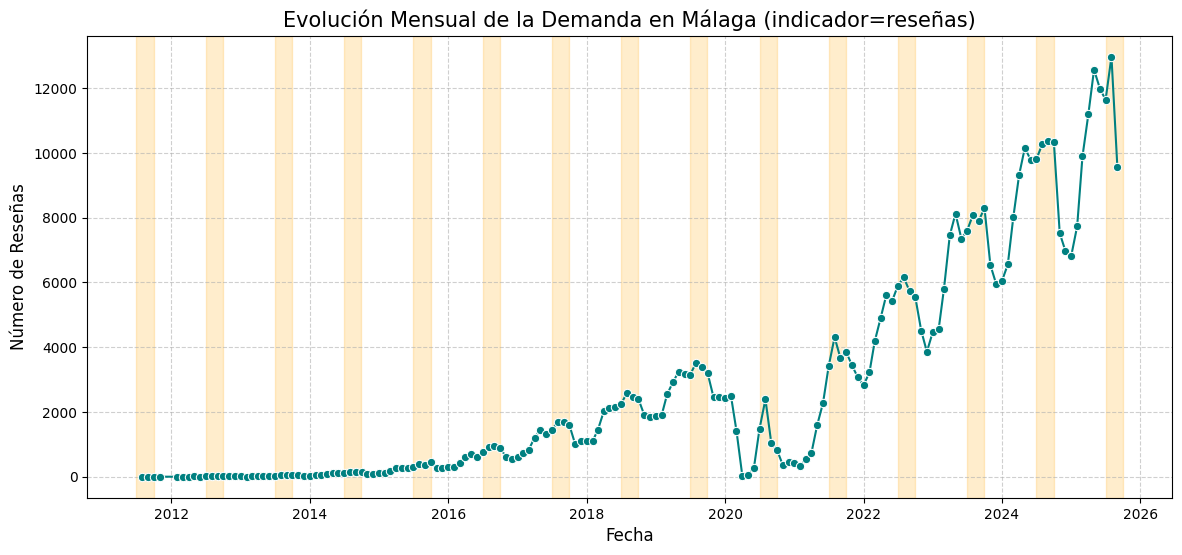

In [22]:
# Visualización de la serie temporal: Para ver si existen los famosos "picos" de julio, agosto y septiembre
plt.figure(figsize=(14, 6))
sns.lineplot(data=resenas_por_mes, x='month_year', y='num_reviews', marker='o', color='teal')

plt.title('Evolución Mensual de la Demanda en Málaga (indicador=reseñas)', fontsize=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de Reseñas', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Añadimos líneas verticales para marcar los veranos (Q3)
for year in resenas_por_mes['month_year'].dt.year.unique():
    plt.axvspan(pd.Timestamp(f'{year}-07-01'), pd.Timestamp(f'{year}-09-30'), 
                color='orange', alpha=0.2, label='Verano (Q3)' if year == 2024 else "")

plt.show()

Al haber días con muchas reseñas y días con cero, la línea sube y baja violentamente. Además, el eje X está colapsado porque hay demasiada información histórica.

Para que el gráfico sea legible y útil para nuestro análisis de estacionalidad, necesitamos "suavizar" la curva agrupando por meses y filtrar el ruido.

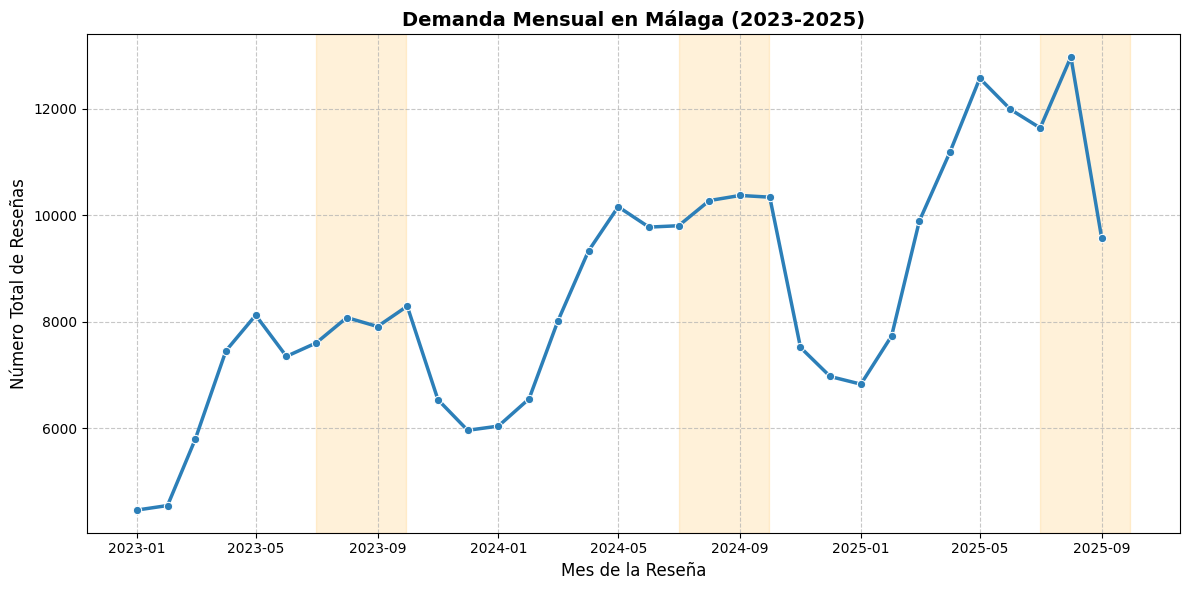

In [23]:
# La Solución: Agrupar y Filtrar
# Vamos a añadir el filtrado por años (2023-2025) para que el gráfico sea "limpio" y se pueda ver claramente si el verano sube un 50%.

# 1. FILTRAR: Nos quedamos solo con los últimos años para ver la realidad actual
df_reciente = df_merged[df_merged['date'].dt.year >= 2023].copy()

# 2. AGRUPAR por Mes: Para eliminar el "diente de sierra"
# Creamos una columna Mes-Año
df_reciente['month_year'] = df_reciente['date'].dt.to_period('M')
resenas_mensuales = df_reciente.groupby('month_year').size().reset_index(name='conteo')

# Convertir a timestamp para que el eje X se vea bien
resenas_mensuales['month_year'] = resenas_mensuales['month_year'].dt.to_timestamp()

# 4. Gráfico Limpio
plt.figure(figsize=(12, 6))
sns.lineplot(data=resenas_mensuales, x='month_year', y='conteo', marker='o', linewidth=2.5, color='#2c7fb8')

plt.title('Demanda Mensual en Málaga (2023-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Mes de la Reseña', fontsize=12)
plt.ylabel('Número Total de Reseñas', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Resaltar los veranos para la hipótesis
for year in [2023, 2024, 2025]:
    plt.axvspan(pd.Timestamp(f'{year}-07-01'), pd.Timestamp(f'{year}-09-30'), 
                color='orange', alpha=0.15)

plt.tight_layout()
plt.show()

In [24]:
# Vemos el nombre de la columna, nos interesa la de los distritos
df_merged.columns

Index(['date', 'id', 'neighbourhood', 'month_year'], dtype='str')

In [25]:
# Vemos cuántos distritos hay
conteo_distritos = df_merged['neighbourhood'].value_counts()
print(conteo_distritos)

neighbourhood
Centro                  342156
Carretera de Cadiz       41727
Este                     33426
Cruz De Humilladero      17267
Bailen-Miraflores        15360
Churriana                 5344
Palma-Palmilla            2781
Ciudad Jardin             2604
Teatinos-Universidad      1926
Puerto de la Torre        1686
Campanillas                871
Name: count, dtype: int64


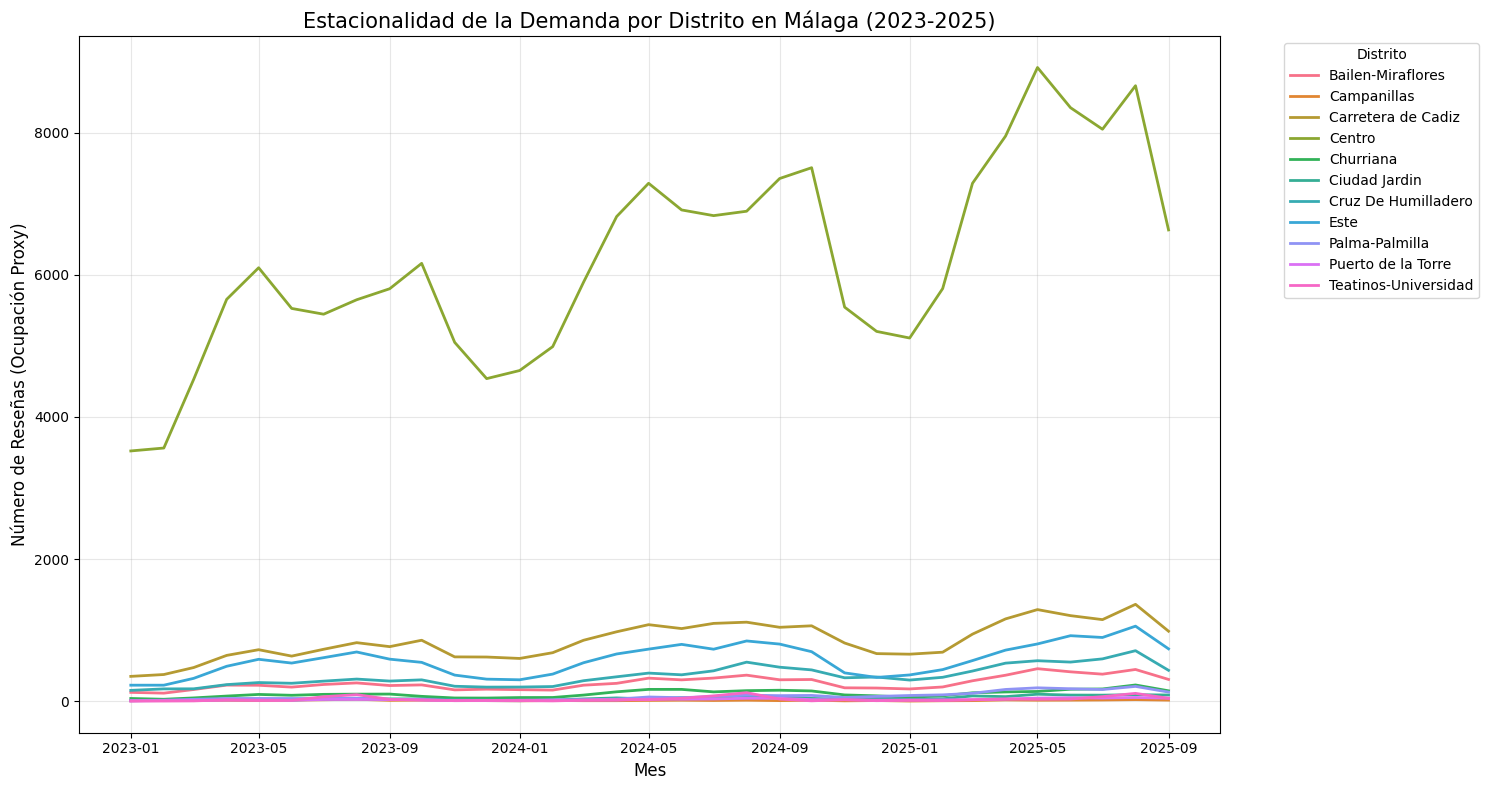

In [26]:
# 1. Preparar datos
df_merged['date'] = pd.to_datetime(df_merged['date'])
# Filtramos desde 2023 para que el gráfico no sea un caos de líneas
df_plot = df_merged[df_merged['date'].dt.year >= 2023].copy()
df_plot['month_year'] = df_plot['date'].dt.to_period('M').dt.to_timestamp()

# 2. Agrupamos por mes y distrito
df_counts = df_plot.groupby(['month_year', 'neighbourhood']).size().reset_index(name='num_reviews')

# 3. Gráfico Bivariante (Tiempo + Distrito)
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_counts, x='month_year', y='num_reviews', hue='neighbourhood', linewidth=2)

plt.title('Estacionalidad de la Demanda por Distrito en Málaga (2023-2025)', fontsize=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Número de Reseñas (Ocupación Proxy)', fontsize=12)
plt.legend(title='Distrito', bbox_to_anchor=(1.05, 1), loc='upper left') # Leyenda fuera para que no moleste
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El Distrito Centro está muy por encima de los demás en volumen. Esto confirma que el Centro es el motor absoluto del turismo en Málaga. Incluso en los valles (invierno), el Centro tiene más reseñas que el pico más alto de la mayoría de los otros distritos. Eso ya apunta a la estabilidad.

### 2. Análisismultivariante (Los Números)
Vamos a calcular el dato exacto. Vamos a comparar el Q2 (Abril, Mayo, Junio) contra el Q3 (Julio, Agosto, Septiembre) de 2024.

                         Q1     Q2     Q3     Q4  Crecimiento_%
neighbourhood                                                  
Teatinos-Universidad     35     92    234     42     154.347826
Palma-Palmilla           53    146    237    209      62.328767
Puerto de la Torre       51     82    122     66      48.780488
Ciudad Jardin            71    135    195    116      44.444444
Cruz De Humilladero     702   1118   1463   1118      30.858676
Bailen-Miraflores       552    884   1001    687      13.235294
Este                   1232   2204   2390   1437       8.439201
Carretera de Cadiz     2149   3082   3253   2556       5.548345
Centro                15539  21015  21077  18252       0.295027
Campanillas              31     41     41     37       0.000000
Churriana               198    473    442    316      -6.553911


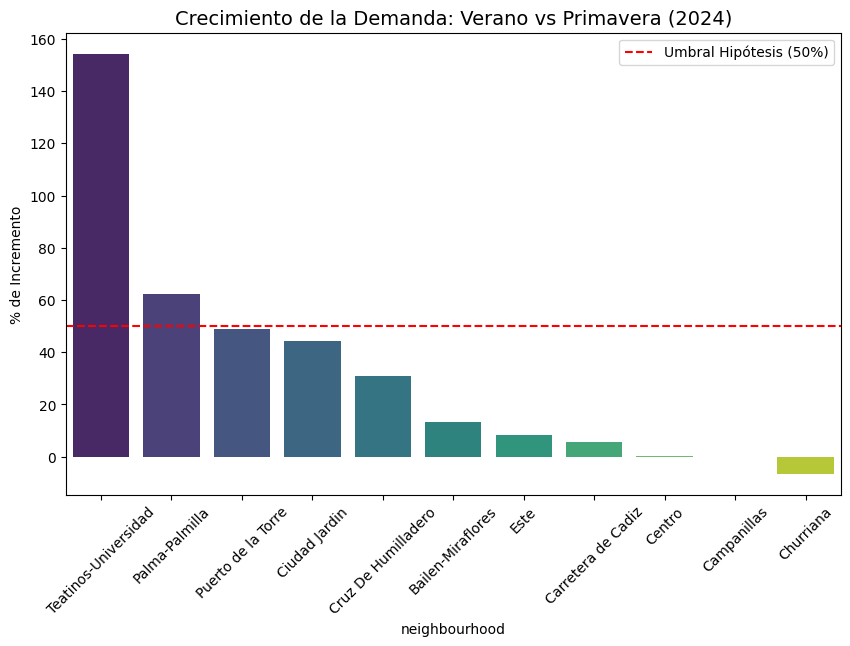

In [27]:
# 1. Filtramos solo el año 2024 (último completo y fiable)
df_2024 = df_merged[df_merged['date'].dt.year == 2024].copy()
df_2024['trimestre'] = df_2024['date'].dt.quarter

# 2. Agrupamos por Barrio y Trimestre (Q2 es el 2, Q3 es el 3)
resumen = df_2024.groupby(['neighbourhood', 'trimestre']).size().unstack(fill_value=0)

# 3. Renombramos columnas
resumen.columns = [f'Q{col}' for col in resumen.columns]

# 4. Calcular el % de crecimiento del Q3 respecto al Q2 con la fórmula ((Q3 - Q2) / Q2) * 100
if 'Q2' in resumen.columns and 'Q3' in resumen.columns:
    resumen['Crecimiento_%'] = ((resumen['Q3'] - resumen['Q2']) / resumen['Q2']) * 100
    
    # Ordenar por los que más crecen (más estacionales)
    resumen = resumen.sort_values(by='Crecimiento_%', ascending=False)
    print(resumen)
    
    # --- GRÁFICO MULTIVARIANTE ---
    plt.figure(figsize=(10, 6))
    sns.barplot(x=resumen.index, y=resumen['Crecimiento_%'], palette='viridis')
    plt.axhline(50, color='red', linestyle='--', label='Umbral Hipótesis (50%)')
    plt.title('Crecimiento de la Demanda: Verano vs Primavera (2024)', fontsize=14)
    plt.xticks(rotation=45)
    plt.ylabel('% de Incremento')
    plt.legend()
    plt.show()
else:
    print("Error: No se encontraron datos suficientes para Q2 o Q3 de 2024.")

### Conclusiones

1. Validación de la Hipótesis: El Crecimiento del 50%  

La hipótesis dice que la demanda presenta un pico de crecimiento superior al 50% en el Q3 (verano).

Resultados Mixtos: La hipótesis no se cumple de forma generalizada, pero sí en distritos específicos.

Líderes de Crecimiento: Solo Teatinos-Universidad (154.3%) y Palma-Palmilla (62.3%) superan el umbral del 50% marcado por la línea roja.

Cerca del objetivo: Puerto de la Torre (48.7%) y Ciudad Jardín (44.4%) se quedan muy cerca del umbral.

El caso de los "Gigantes": Los distritos con más volumen (como Centro o Carretera de Cádiz) tienen crecimientos muy bajos (0.29% y 5.5%). Esto es lógico: mover un volumen de 15,000 reseñas un 50% extra es mucho más difícil que mover un volumen de 100 reseñas.

2. Estabilidad en el Distrito Centro
La hipótesis afirma que el Distrito Centro mantiene una demanda más estable.

Confirmación Total: Los datos respaldan esto plenamente.

El Centro pasa de 15,539 (Q1) a 18,252 (Q4), con un pico de 21,077 en Q3.

Su crecimiento porcentual es de apenas el 0.29% (suponiendo que Crecimiento_% compare Q3 vs Q2 o similar). Esto indica que el Centro está siempre "lleno" o a un nivel de actividad muy alto, sin fluctuaciones violentas de estacionalidad. Es el motor constante de la ciudad.

3. Análisis del Gráfico Multivariante
El gráfico de barras que hemos generado es una herramienta de clasificación de estacionalidad.

Zonas de Alta Estacionalidad (Barras Moradas/Azules): Teatinos y Palma-Palmilla son zonas "veraniegas" o de picos específicos. Su demanda depende mucho de la época del año.

Zonas de Estabilidad Madura (Barras Verdes/Planos): Carretera de Cádiz, Centro y Campanillas. Tienen mucha demanda (en el caso de los dos primeros) pero no dependen del verano para atraer gente; funcionan todo el año.

Valores Atípicos: Churriana muestra un crecimiento negativo. Esto es un hallazgo importante ¿Por qué baja la demanda allí en verano mientras en el resto sube?